# **ML PROJECT - EEG PD**
## Imports & Configuration

In [1]:
!pip install -q mne
!pip install captum
!pip install scikit-posthocs

In [2]:
import os
import warnings
import copy
warnings.filterwarnings("ignore", category=RuntimeWarning)

import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from matplotlib.lines import Line2D

from scipy.optimize import linear_sum_assignment
from scipy.stats import mode, pearsonr, entropy, pointbiserialr, zscore
import scipy.stats as stats
from scipy.spatial import ConvexHull
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist, squareform
from sklearn.linear_model import LinearRegression
from scipy.optimize import linear_sum_assignment
from sklearn.manifold import TSNE
from scipy.integrate import trapezoid
from scipy.signal import spectrogram
import scikit_posthocs as sp

import mne
from mne.time_frequency import psd_array_welch
from sklearn.neighbors import NearestNeighbors
from random import sample

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.decomposition import PCA
import umap
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
	silhouette_score, davies_bouldin_score, calinski_harabasz_score,
	adjusted_rand_score, normalized_mutual_info_score, f1_score, confusion_matrix, ConfusionMatrixDisplay,
	classification_report, accuracy_score, roc_curve, auc, roc_auc_score, make_scorer, balanced_accuracy_score
)
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score, GroupKFold, cross_validate, GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import SVC

import torch
import torch.nn as nn
from torch.utils.data import Dataset, TensorDataset, DataLoader, Subset, WeightedRandomSampler
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from collections import Counter

from imblearn.over_sampling import SMOTE

from captum.attr import IntegratedGradients
from sklearn.ensemble import RandomForestClassifier



In [3]:
plt.ioff()
RANDOM_STATE = 42

All models are fixed with a random seed to ensure reproducibility. Importantly, the analysis deliberately relies on **multiple clustering algorithms and dimensionality reduction techniques** to avoid conclusions driven by a single method.

# 1. DATASET DISCOVERY & SANITY CHECKS

The dataset consists of **resting-state EEG recordings** from Parkinson’s disease patients and healthy controls. The overarching goal of the unsupervised analysis is **not classification**, but rather to characterize the **intrinsic geometry** of EEG feature space.

## Mount & Sanity checks

In [4]:
from google.colab import drive
drive.mount("/content/drive")

DATA_ROOT = Path("/content/drive/MyDrive/ds004584")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
set_files = sorted(DATA_ROOT.glob("sub-*/eeg/*.set"))
print(f"Found {len(set_files)} EEG recordings")

Found 149 EEG recordings


In [6]:
# Load one example recording (sanity check only)
example_file = set_files[0]
raw = mne.io.read_raw_eeglab(example_file, preload=False, verbose=False)

print("Sampling frequency:", raw.info["sfreq"])
print("Number of channels:", len(raw.ch_names))
print("Duration (seconds):", raw.n_times / raw.info["sfreq"])
print("First 10 channel names:", raw.ch_names[:10])

Sampling frequency: 500.0
Number of channels: 63
Duration (seconds): 281.66
First 10 channel names: ['Fp1', 'Fz', 'F3', 'F7', 'FT9', 'FC5', 'FC1', 'C3', 'T7', 'TP9']


## Participants, labels and cognitive scores

We ask whether latent structure emerges naturally from the data, and if so, whether this structure aligns with disease diagnosis or clinical variables such as age, cognition (MOCA), or motor severity (UPDRS).

In [7]:
participants = pd.read_csv(
    DATA_ROOT / "participants_clin_cog.csv"#,sep="\t"
)

cognitive_cols = ['NIH FICAT', 'NIH DCCST', 'NIH PCPST', 'NIH PSMT','NIH PVT']

# Keep only rows where all cognitive tests are not NaN
participants = participants.dropna(subset=cognitive_cols).copy()

subject_ids_cog = participants["participant_id"].tolist()

participants["label_num"] = participants["GROUP"].map(
    {"Control": 0, "PD": 1}
)

participants["GROUP"].value_counts()

,count
GROUP,
PD,92
Control,46


In [8]:
subject_ids = [file.parts[-3] for file in set_files]
valid_subjects = [subj for subj in subject_ids if subj in participants["participant_id"].values]

subject_ids_cog = set(valid_subjects)

set_files = sorted(
    f for f in DATA_ROOT.glob("sub-*/eeg/*.set")
    if f.parts[f.parts.index("eeg") - 1] in subject_ids_cog
)

In [9]:
age = participants.loc[participants["participant_id"].isin([f.parts[-3] for f in set_files]),"AGE"].values
moca = participants.loc[participants["participant_id"].isin([f.parts[-3] for f in set_files]),"MOCA"].values
updrs = participants.loc[participants["participant_id"].isin([f.parts[-3] for f in set_files]),"UPDRS"].values
nih_ficat = participants.loc[participants["participant_id"].isin([f.parts[-3] for f in set_files]),"NIH FICAT"].values


# Sanity check
if len(age) == len(valid_subjects):
  print("AGE vector shape:", age.shape)
else:
  raise ValueError("AGE vector length mismatch")

y_true = participants.set_index("participant_id").loc[valid_subjects, "label_num"].values

AGE vector shape: (138,)


## Common channels

In [10]:
def load_eeg(file_path: Path) -> mne.io.Raw:
  # Load using mne
  return mne.io.read_raw_eeglab(
    file_path,
    preload=True,
    verbose=False
  )

In [11]:
# Determine common channel set (intersection across subjects)
channel_sets = []

for file in set_files:
  raw = load_eeg(file)
  channel_sets.append(set(raw.ch_names))

common_channels = sorted(set.intersection(*channel_sets))
print(f"Using {len(common_channels)} common channels")

Using 60 common channels


In [12]:
selected_channels = ['P8', 'PO7', 'CP1', 'CP2', 'P6', 'O2', 'P4', 'F4']

## Global cognitive score

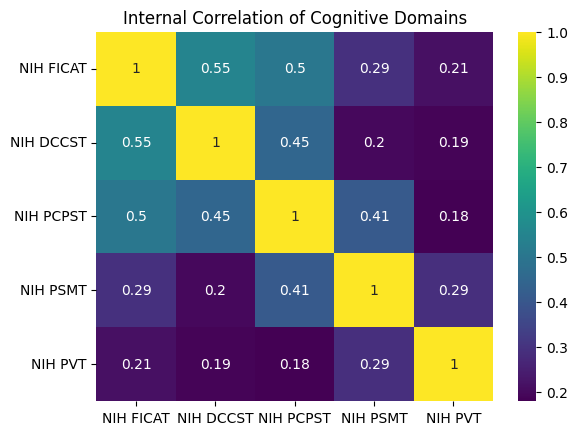

In [13]:
# Check how well the NIH scores correlate with each other
internal_corr = participants[cognitive_cols].corr()

sns.heatmap(internal_corr, annot=True, cmap='viridis')
plt.title("Internal Correlation of Cognitive Domains")
plt.show()

FICAT, DCCST, and PCPST are all strongly inter-correlated ($0.45$ to $0.55$). These three tests (Inhibitory Control, Cognitive Flexibility, and Processing Speed) are clearly moving together. They represent a "Frontal-Executive" core.PSMT and PVT have much weaker ties to that core (dropping as low as $0.18$). These measure Memory and Vocabulary/Vision, which are likely being preserved or affected differently in the group.

In [14]:
# Mean & Std of the Healthy Controls ONLY
controls = participants[participants['GROUP'] == 'Control']
core_tests = ['NIH FICAT', 'NIH DCCST', 'NIH PCPST']

control_means = controls[core_tests].mean()
control_stds = controls[core_tests].std()

# Z-scores for EVERYONE based on those Control Norms
z_scores = (participants[core_tests] - control_means) / control_stds
participants['Executive_Composite'] = z_scores.mean(axis=1)

def normative_map(z):
    if z < -1.0: return 2 # Impaired
    if z < 0.0:  return 1 # Standard
    return 0              # Preserved

participants['cog_tier'] = participants['Executive_Composite'].apply(normative_map)
participants['cog_binary'] = (participants['cog_tier'] == 2).astype(int)


In [15]:

# 1 = Impaired (Tier 2), 0 = Not Impaired (Tiers 0 & 1)
participants['cog_binary'] = participants['cog_tier'].apply(lambda x: 1 if x == 2 else 0)

print(f"-  CLINICAL LABEL SUMMARY (N={len(participants)})  -")
print("\nGroup Breakdown of Tiers (0=Impaired, 1=Standard, 2=Preserved):")
print(participants.groupby('GROUP')['cog_tier'].value_counts().unstack().fillna(0).astype(int))

print()
print("Binary Distribution (1=Impaired, 0=Not_Impaired):")
binary_counts = participants.groupby('GROUP')['cog_binary'].value_counts().unstack().fillna(0).astype(int)
binary_counts.columns = ['Not_Impaired (0)', 'Impaired (1)']
print(binary_counts)

-  CLINICAL LABEL SUMMARY (N=138)  -

Group Breakdown of Tiers (0=Impaired, 1=Standard, 2=Preserved):
cog_tier   0   1   2
GROUP               
Control   20  23   3
PD        12  36  44

Binary Distribution (1=Impaired, 0=Not_Impaired):
         Not_Impaired (0)  Impaired (1)
GROUP                                  
Control                43             3
PD                     48            44


To establish a biologically grounded ground-truth for cognitive status, participants were categorized using a normative-referenced composite score targeting the frontal-executive domain. Recognizing that Inhibitory Control (FICAT), Cognitive Flexibility (DCCST), and Processing Speed (PCPST) exhibited strong inter-correlation ($r = 0.45$ to $0.55$), an Executive Composite was calculated. This was achieved by transforming raw scores into Z-scores based exclusively on the distribution of the Healthy Control cohort ($N=46$). By using the healthy population as the baseline yardstick, we ensured that "Impairment" was defined not by arbitrary clusters, but by significant deviation from neurotypical performance. Specifically, a threshold of $Z < -1.0$ (representing the bottom 15% of healthy performance) was used to define Clinical Impairment (Tier 0), while $Z \ge 0$ identified Preserved function (Tier 2). This rigorous stratification provides a stable clinical anchor for the subsequent unsupervised EEG clustering, allowing us to test whether natural brain-wave patterns respect these established clinical boundaries.

# 2. CORE PROCESSING UTILITIES + FEATURE CONSTRUCTION

## Feature construction

In [16]:
def compute_psd(raw, fmin=0.5, fmax=40.0):
  data = raw.get_data()  # shape (n_channels, n_times)
  sfreq = raw.info["sfreq"] # Sampling freq (Hz) is required to map samples to physical frequencies

  # PSD using Welch’s method - avg periodograms over overlapping windows, reducing variance and making it well-suited for resting-state EEG
  psd, freqs = psd_array_welch(data, sfreq=sfreq, fmin=fmin, fmax=fmax,
                                n_fft=2048, average="mean", verbose=False)
  return psd, freqs

def get_band_features(psd, freqs, channels, bands):
  values, names = [], []
  for ch_idx, ch_name in enumerate(channels):
    for b_name, (fmin, fmax) in bands.items():
      idx = np.where((freqs >= fmin) & (freqs < fmax))[0]
      val = psd[ch_idx, idx].mean()
      values.append(val)
      names.append(f"{ch_name}_{b_name}")
  return np.array(values), names

Multiple feature representations are constructed to probe EEG structure at different levels of abstraction. This includes high-dimensional spectral representations as well as biologically motivated low-frequency summaries. Importantly, features are constructed **per channel × band**, preserving spatial information and enabling interpretability of latent axes.

If we focus on known PD-sensitive frequencies, does diagnostic separation improve?
Prior work identified the 0.5–12 Hz range as maximally discriminative between PD and control subjects, spanning delta, theta, and low-alpha bands known to be abnormal in PD.

LEAPD bandpower features were included as a hypothesis-driven, disease-optimized representation, complementary to generic spectral features. This allows us to assess whether unsupervised structure aligns more strongly with PD-specific spectral abnormalities or emerges independently of disease-informed feature design.

In [17]:
LEAPD_BANDS = {
    "delta_leapd": (0.5, 4),
    "theta_leapd": (5, 8),
    "l_alpha_leapd": (9, 12)
}

Inclusion of a "sham band" for specificity control

In [18]:
SHAM_BANDS = {
  "delta":(0.5, 4),
  "theta":(5, 8),
  "alpha":(9, 12),
  "beta":(13, 30), # Additoinal band for checking
}

In [19]:
def construct_master_features(set_files, channel_list):
  # (one per subject)
  X_full_list = []
  X_low_list = []
  X_sham_list = []

  print(f"Starting processing for {len(set_files)} files...")

  for file in tqdm(set_files):
      try:
        raw = mne.io.read_raw_eeglab(file, preload=True, verbose=False)
        raw.pick(channel_list)

        # PSD once (0.5 to 40 Hz)
        psd, freqs = compute_psd(raw, fmin=0.5, fmax=40.0)

        # FULL PSD
        X_full_list.append(np.log10(psd.flatten() + 1e-12))

        # LOW FREQ (0.5-12Hz) + RATIOS
        # Band powers per channel
        bp_leapd, _ = get_band_features(psd, freqs, channel_list, LEAPD_BANDS)

        # Reshape to (Channels, Bands)
        bp_reshaped = bp_leapd.reshape(len(channel_list), -1)
        theta = bp_reshaped[:, 1] # Index 1 is Theta (5-8Hz)
        alpha = bp_reshaped[:, 2] # Index 2 is Alpha (9-12Hz)

        # TAR per channel
        tar_vals = theta / (alpha + 1e-12)
        # Global TAR (One value per subject)
        global_tar = np.mean(theta) / (np.mean(alpha) + 1e-12)

        # [24 bandpowers, 8 TARs, 1 Global TAR]
        low_freq_combined = np.hstack([bp_leapd, tar_vals, [global_tar]])
        X_low_list.append(low_freq_combined)

        # SHAM BAND
        bp_sham, _ = get_band_features(psd, freqs, channel_list, SHAM_BANDS)
        X_sham_list.append(bp_sham)

      except Exception as e:
        print(f"Error processing {file.name}: {e}")

  # Lists to final 2D NumPy arrays (Rows = Subjects, Cols = Features)
  return {
    "full_psd": np.array(X_full_list),
    "low_freq": np.array(X_low_list),
    "sham_band": np.array(X_sham_list)
  }



In [20]:
FEATURES = construct_master_features(set_files, selected_channels)

print()
print("-  FINAL INTEGRITY CHECK  -")
for key, data in FEATURES.items():
  print(f"Set: {key} | Shape: {data.shape}")

Starting processing for 138 files...


100%|██████████| 138/138 [00:31<00:00,  4.31it/s]


-  FINAL INTEGRITY CHECK  -
Set: full_psd | Shape: (138, 1288)
Set: low_freq | Shape: (138, 33)
Set: sham_band | Shape: (138, 32)


In [21]:
bands = ["Delta", "Theta", "L-Alpha"]

profile_cols = []

# First 24: Band powers (Channel_Band)
for ch in selected_channels:
    for b in bands:
        profile_cols.append(f"{ch}_{b}")

# Next 8: TAR per channel
for ch in selected_channels:
    profile_cols.append(f"{ch}_TAR")

# Final 1: Global TAR
profile_cols.append("Global_TAR")

# Verify the length matches your data columns (Should be 33)
print(f"Total Features: {len(profile_cols)}")

Total Features: 33


Sizes ok:

low_freq = $(8 \text{ channels} \times 3 \text{ bands}) + 8 \text{ per-channel TARs} + 1 \text{ Global TAR} = \mathbf{33}$

sham_band =  $(8 \text{ channels} \times 4 \text{ bands}) $ = 32

## Outlier Id

In [22]:
# Use Isolation Forest to find subjects whose EEG 'shape' is weird
iso = IsolationForest(contamination=0.05, random_state=RANDOM_STATE) # Top 5%
outlier_preds = iso.fit_predict(FEATURES["low_freq"])

# Identify who they are
outlier_indices = np.where(outlier_preds == -1)[0]
outlier_ids = [valid_subjects[i] for i in outlier_indices]

print(f"Detected {len(outlier_ids)} EEG outliers: {outlier_ids}")

Detected 7 EEG outliers: ['sub-002', 'sub-003', 'sub-014', 'sub-082', 'sub-087', 'sub-095', 'sub-115']


In [23]:
keep_indices = [i for i, sub_id in enumerate(valid_subjects) if sub_id not in outlier_ids]

# Update  participants DataFrame
# This ensures our metadata stays in sync
participants = participants[participants['participant_id'].isin([valid_subjects[i] for i in keep_indices])].reset_index(drop=True)

# Update all feature matrices in dict
# We apply the keep_indices filter to every matrix (low_freq, sham, full)
for key in FEATURES:
    FEATURES[key] = FEATURES[key][keep_indices]

# Update master ID list to reflect the new set
subs_list = [valid_subjects[i] for i in keep_indices]

print(f"--- CLEANING COMPLETE ---")
print(f"Removed: {len(outlier_ids)} subjects.")
print(f"New total N: {len(participants)} (PD: {sum(participants['GROUP']=='PD')}, Control: {sum(participants['GROUP']=='Control')})")

--- CLEANING COMPLETE ---
Removed: 7 subjects.
New total N: 131 (PD: 86, Control: 45)


## Feature Engineering & Normalization

In [24]:
participants_indexed = participants.set_index('participant_id')

y_binary = participants_indexed.loc[subs_list, 'cog_binary'].values

y_tiered = participants_indexed.loc[subs_list, 'cog_tier'].values

y_diag = participants_indexed.loc[subs_list, 'GROUP'].values

print(f"Labels defined for {len(y_binary)} subjects.")

Labels defined for 131 subjects.


In [25]:
# Dict for scaled features to avoid label leakage
FEATURES_SCALED = {}
scaler = StandardScaler()

for key, matrix in FEATURES.items():
    # Fit and transform ONLY on the 131 clean subjects
    FEATURES_SCALED[key] = scaler.fit_transform(matrix)

# CNN

## Definition

In [26]:
diagnosis_lookup = dict(zip(participants['participant_id'], participants['GROUP']))
label_lookup = dict(zip(participants['participant_id'], participants['cog_binary']))
tier_lookup  = dict(zip(participants['participant_id'], participants['cog_tier']))

In [27]:
sfreq = 500 #sampling frequancy
window_sec = 4 #size of the time window
overlap_ratio = 0.5 #overlap between the windows
fmin, fmax = 0.5, 12  #12Hz band pass filter for relevant cognitive frequancies

window_samples = int(window_sec * sfreq) #the ammount of window samples
step = int(window_samples * (1 - overlap_ratio)) #whole window segmentation

In [28]:
#We computed spectrograms for each subject (8 electrodes per subject, 149 samples)
#We devided the full EEG recordings for several time windows (4 sec windows from whole recording, meaning that every subject will get about 30 windows per subject (8Channels, Frequancy, Time))

unique_subject_ids = {uid: i for i, uid in enumerate(participants['participant_id'].unique())}

X_cnn = []
y_cnn = [] # Binary: 0 (Preserved), 1 (Impaired)
y_tier_cnn = [] # Tiered: 0 (Preserved), 1 (Standard), 2 (Risk)
groups_cnn = []


for file_path in tqdm(set_files):
  subj_id = file_path.parts[-3]
  if subj_id not in label_lookup: continue

  try:
    raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)
    raw.pick_channels(selected_channels)
    raw.reorder_channels(selected_channels)
    EEG_data = raw.get_data()[:, :120*sfreq]

    bin_label = label_lookup[subj_id]
    tier_label = tier_lookup[subj_id]
    mapped_group_id = unique_subject_ids[subj_id]
#window bands (for several windows per subject)
    for start in range(0, EEG_data.shape[1] - window_samples + 1, step):
      window_chunk = EEG_data[:, start:start+window_samples]
      specs = []
      for ch in range(window_chunk.shape[0]):
        f, t, Sxx = spectrogram(window_chunk[ch, :], fs=sfreq, nperseg=500, noverlap=375)
        # Windowing 12Hz
        mask_f = (f >= fmin) & (f <= fmax)
        Sxx_log = 10 * np.log10(Sxx[mask_f, :] + 1e-10).astype(np.float32)#db
        specs.append(Sxx_log)#combine all 8 electrodes per subject (for each time window)

      X_cnn.append(np.stack(specs, axis=0))
      y_cnn.append(bin_label)
      y_tier_cnn.append(tier_label)
      groups_cnn.append(mapped_group_id)
  except Exception as e:
    continue

X_cnn = np.array(X_cnn, dtype=np.float32)
y_cnn = np.array(y_cnn, dtype=np.float32)
groups_cnn = np.array(groups_cnn)

# Subject-Level Normalization (within subject normalization, no usage of test data, no training-test information shared)
for g in np.unique(groups_cnn):
  mask = (groups_cnn == g)
  m, s = X_cnn[mask].mean(), X_cnn[mask].std() + 1e-7
  X_cnn[mask] = (X_cnn[mask] - m) / s

  0%|          | 0/138 [00:00<?, ?it/s]

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


  1%|          | 1/138 [00:00<01:15,  1.80it/s]

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


  3%|▎         | 4/138 [00:01<00:38,  3.47it/s]

...

 99%|█████████▊| 136/138 [01:00<00:00,  2.10it/s]

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


 99%|█████████▉| 137/138 [01:00<00:00,  2.13it/s]

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


100%|██████████| 138/138 [01:01<00:00,  2.25it/s]


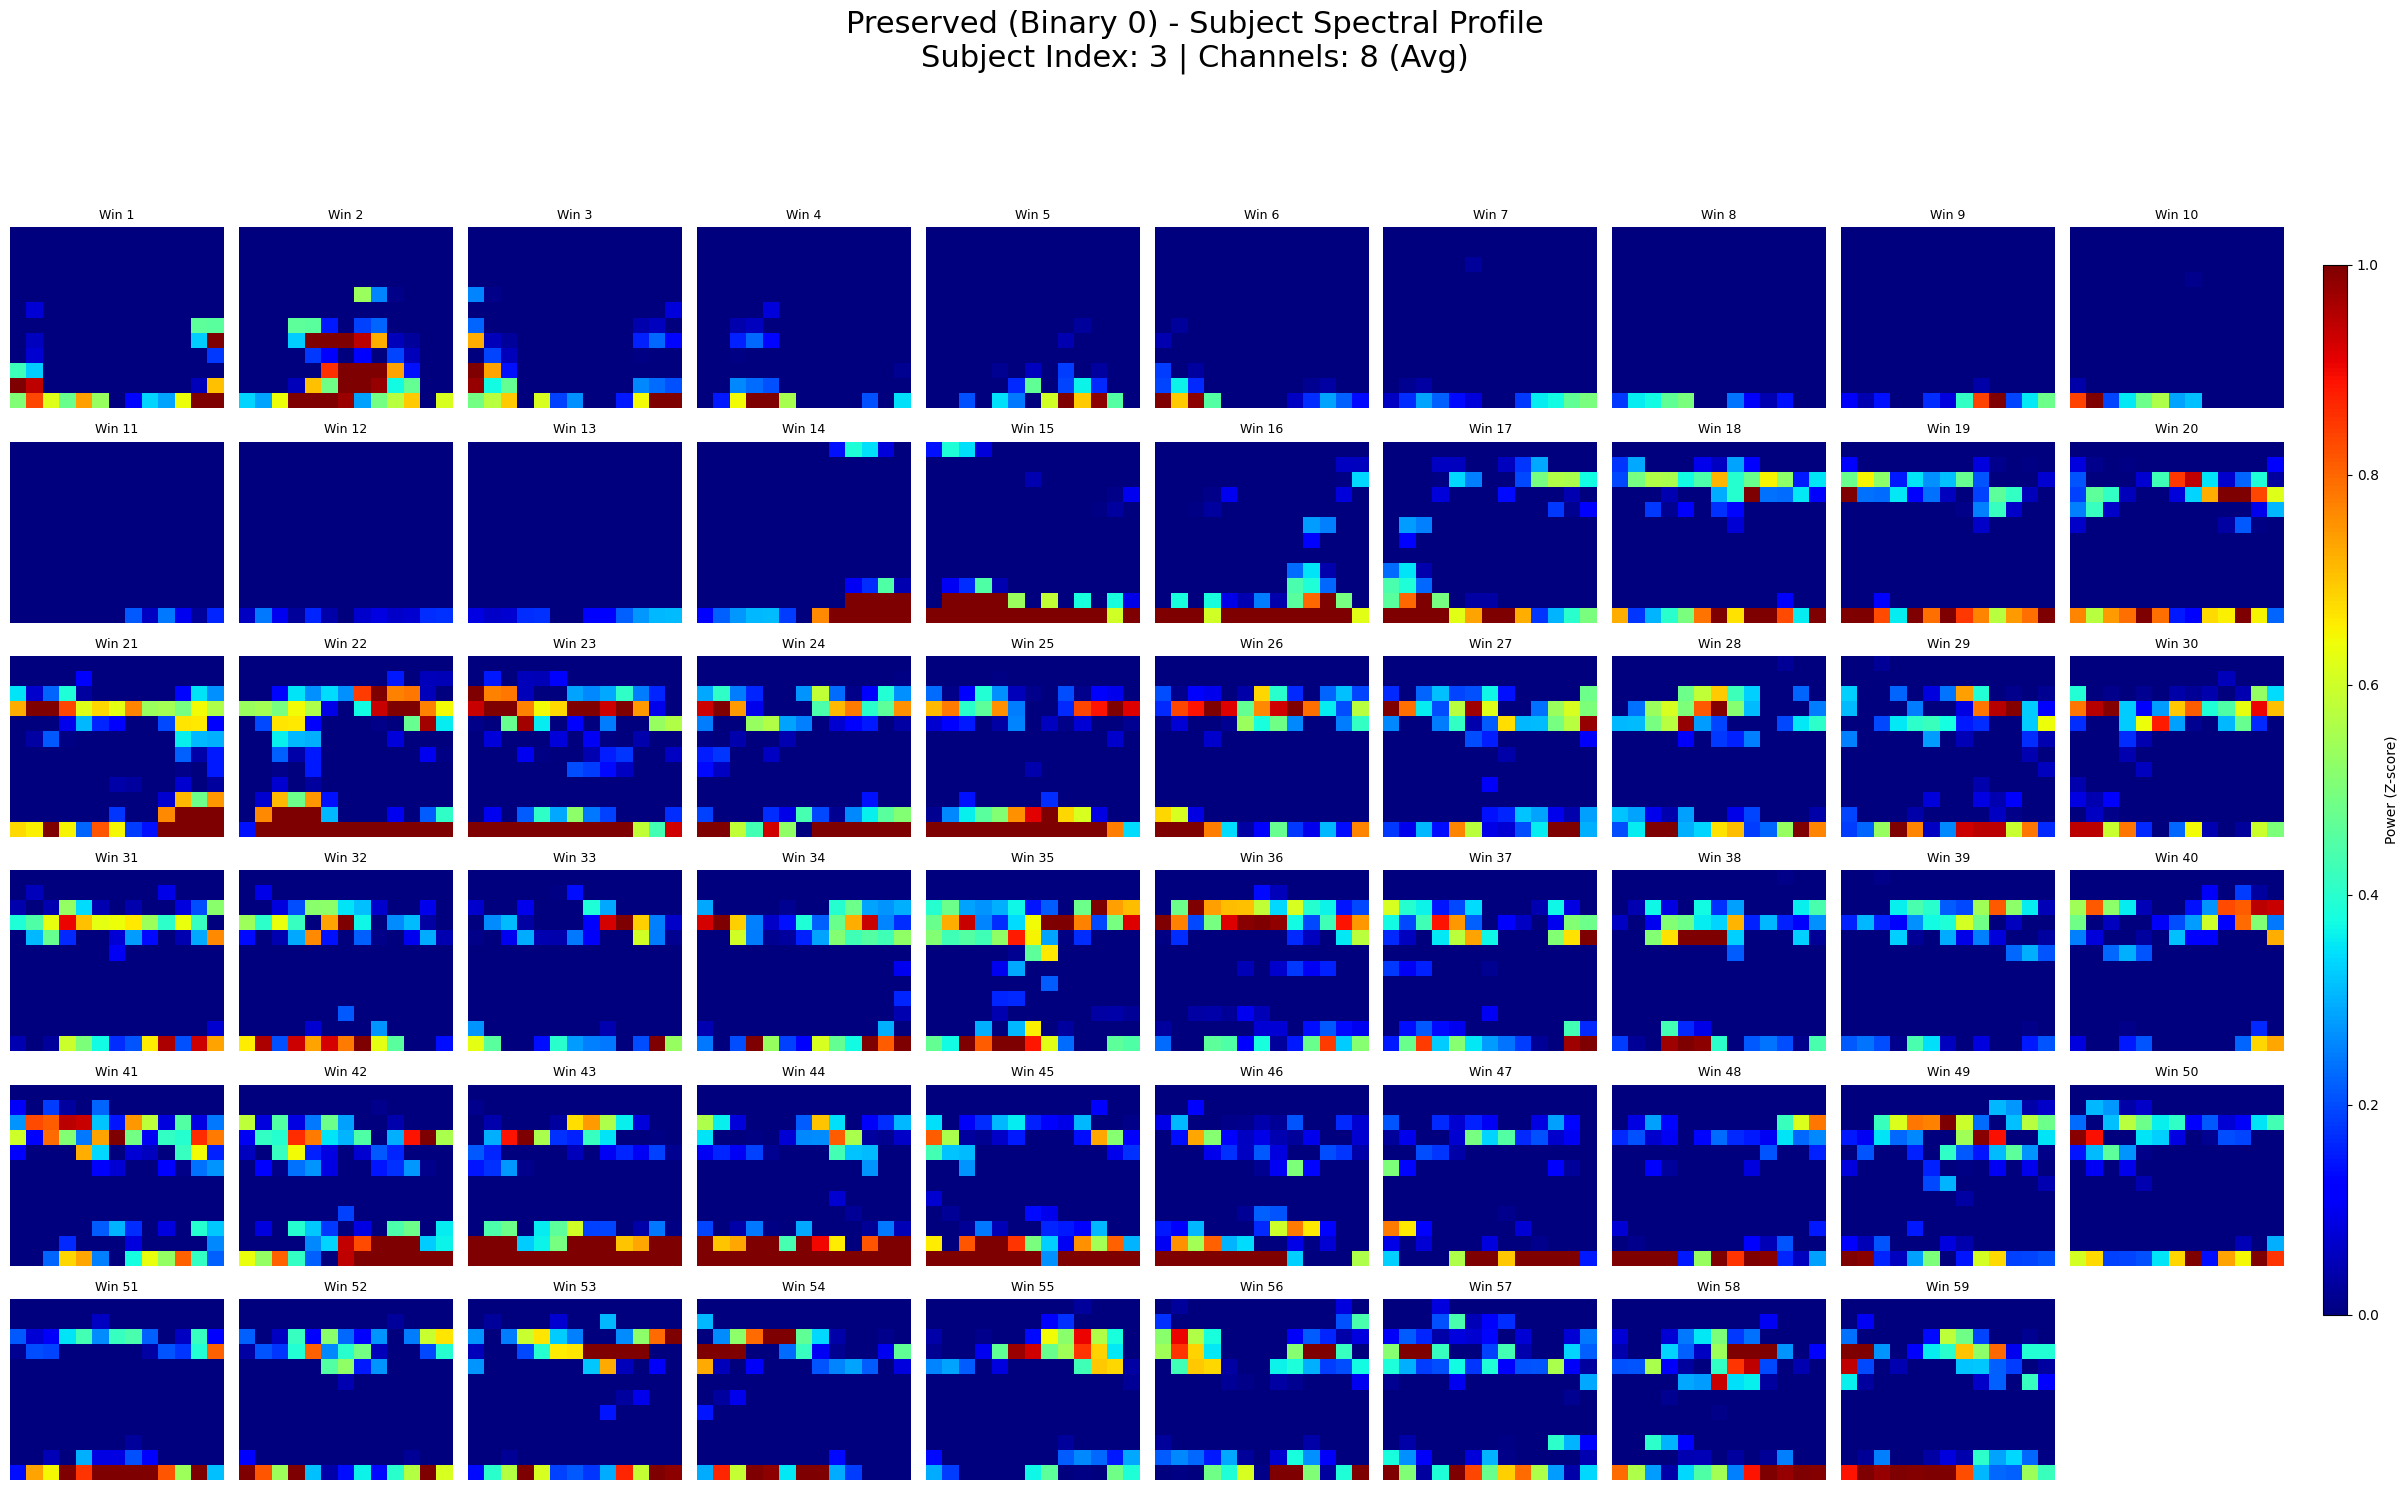

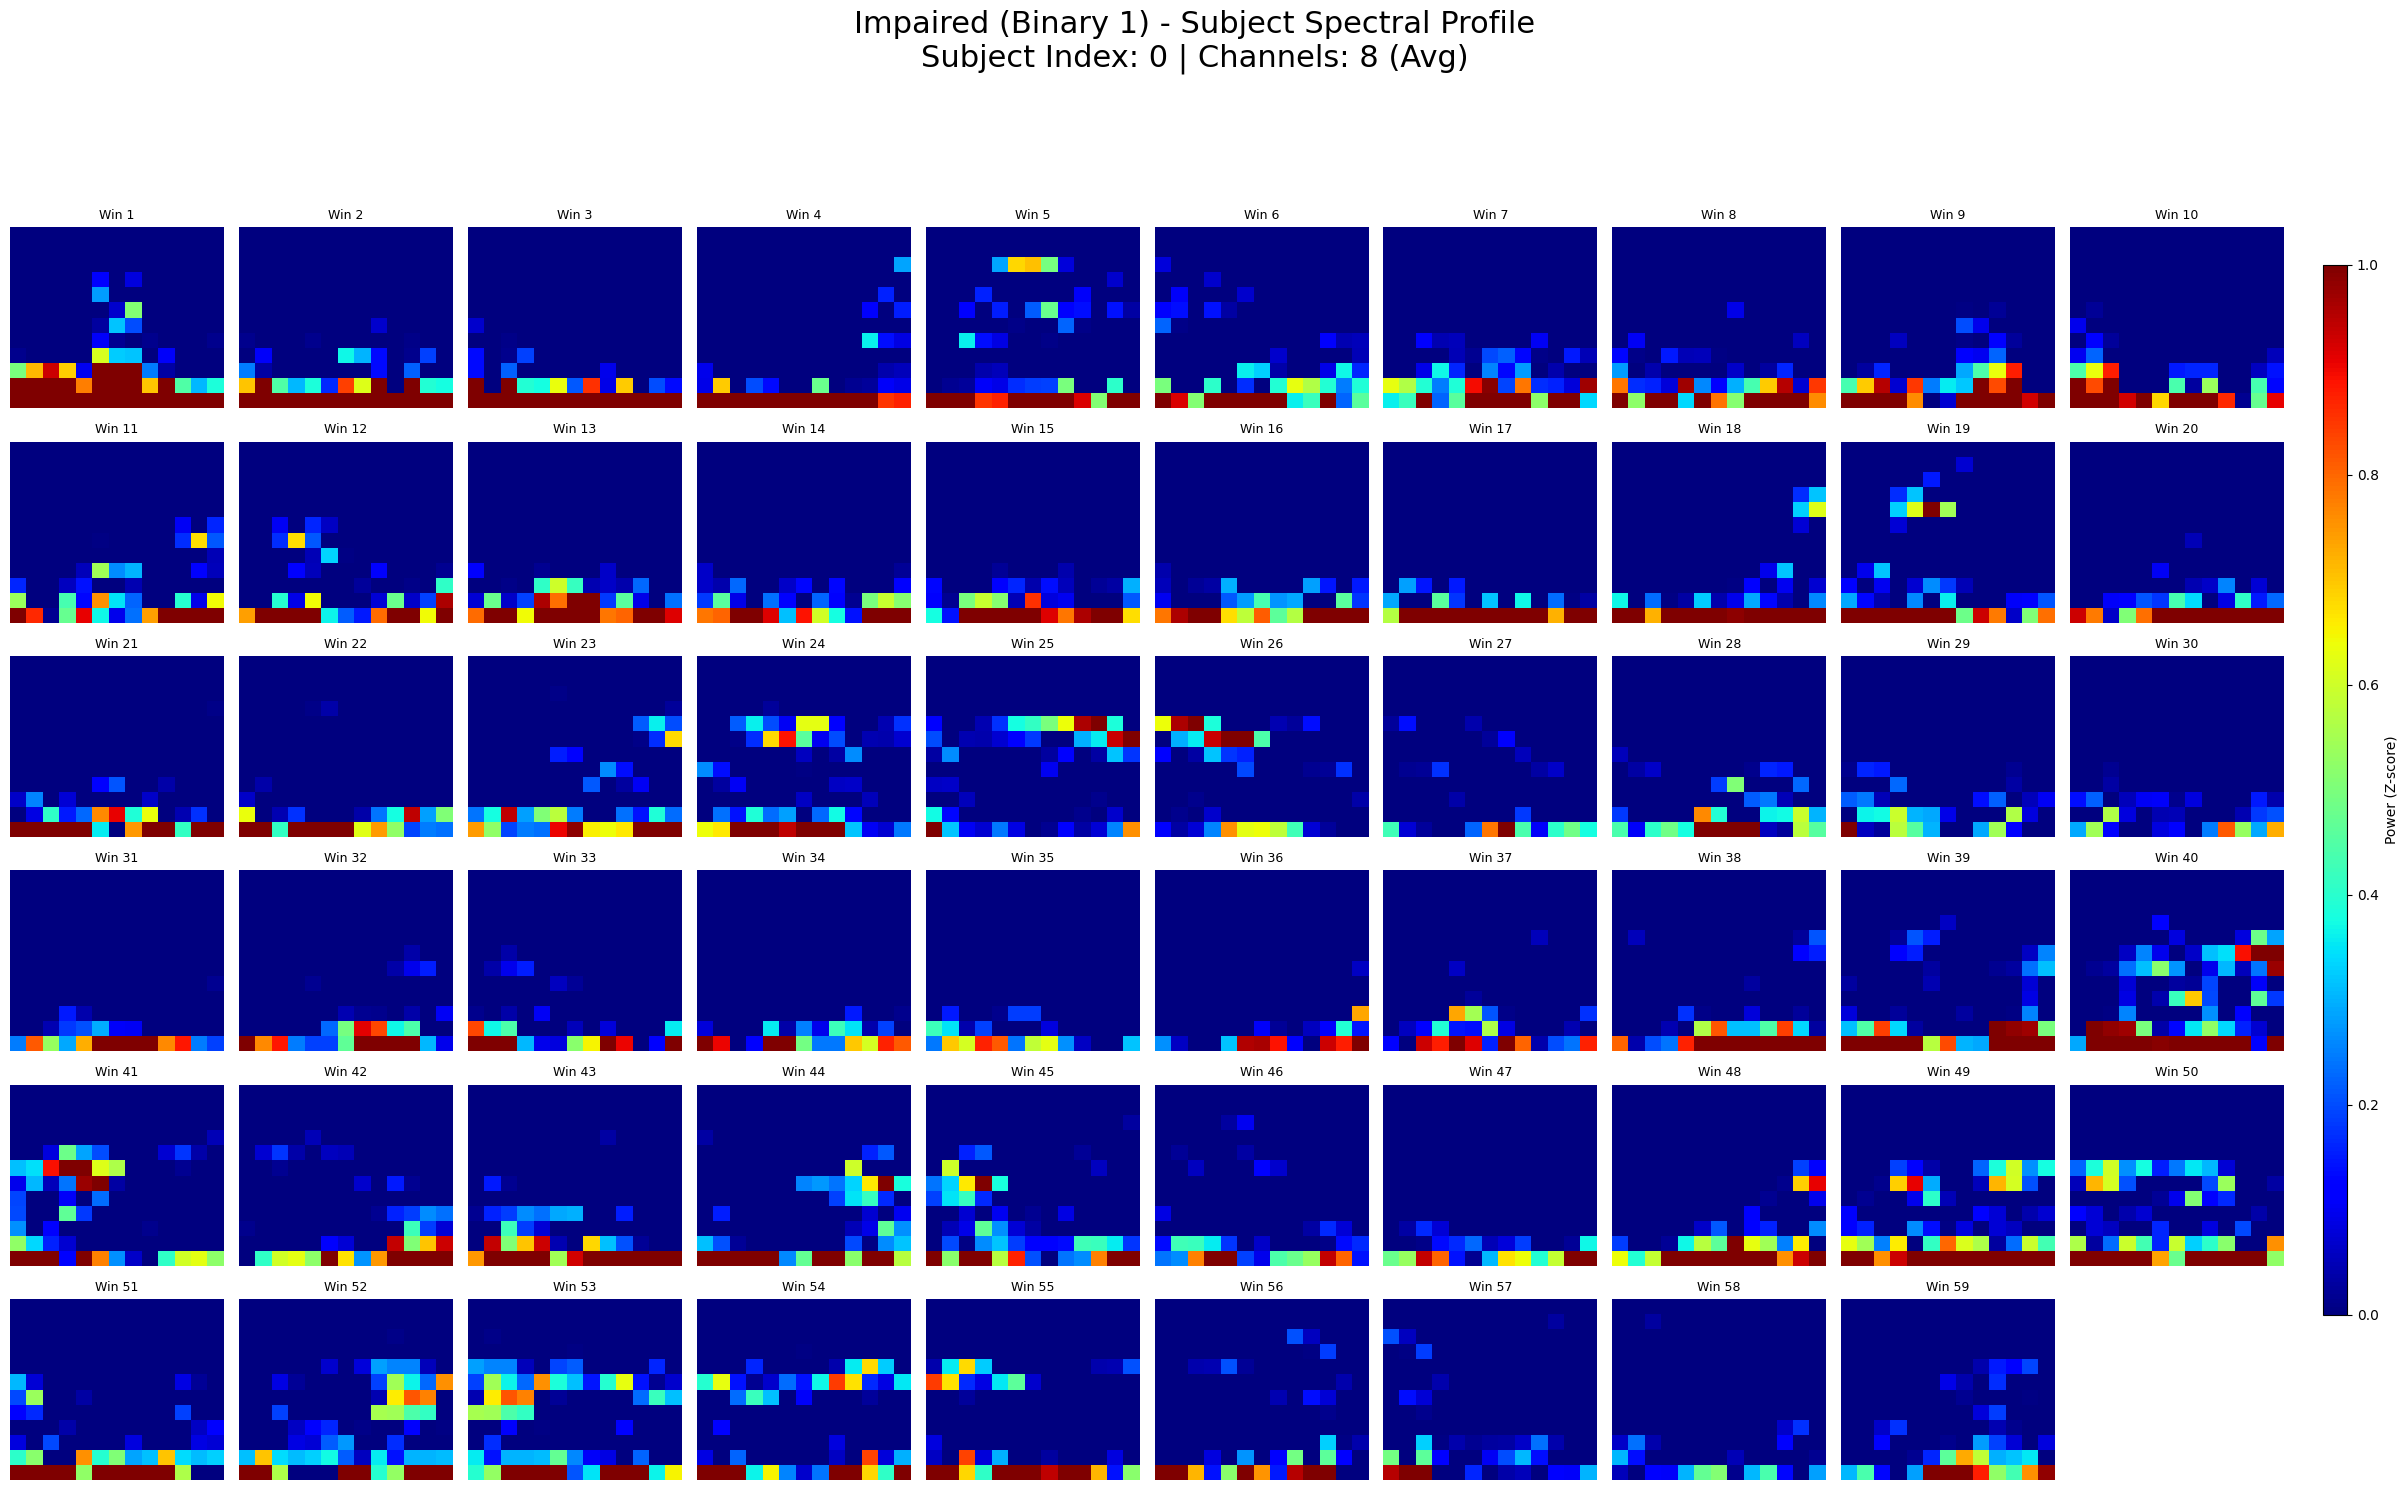

In [29]:
def plot_subject_examples(target_label, title_prefix, label_array=y_cnn):#plot the different examples of subject's spectrograms with different labels

    # Find the first subject belonging to the target class
    # We use label_array (defaults to binary) to find the match
    available_indices = np.where(label_array == target_label)[0]
    if len(available_indices) == 0:
        print(f"No subjects found for label {target_label}")
        return

    subj_id_val = groups_cnn[available_indices[0]]
    indices = np.where(groups_cnn == subj_id_val)[0]

    n_windows = len(indices)
    n_cols = 10
    n_rows = (n_windows // n_cols) + 1

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, n_rows * 2.5))
    fig.suptitle(f"{title_prefix} - Subject Spectral Profile\nSubject Index: {subj_id_val} | Channels: 8 (Avg)",
                 fontsize=22, y=1.02)

    for i in range(n_rows * n_cols):
        row = i // n_cols
        col = i % n_cols
        ax = axes[row, col]

        if i < n_windows:#chose window index
            idx = indices[i]
            # Averaging across the 8 cognitive channels for visualization
            combined_channels = X_cnn[idx].mean(axis=0)

            img = ax.imshow(combined_channels, aspect='auto', origin='lower',
                           cmap='jet', vmin=0, vmax=1)
            ax.set_title(f"Win {i+1}", fontsize=9)
        ax.axis('off')

    plt.tight_layout(rect=[0, 0.03, 0.96, 0.95]) #picture size for visuaization
    cbar_ax=fig.add_axes([0.97, 0.15, 0.01, 0.7])
    fig.colorbar(img, cax=cbar_ax, label='Power (Z-score)')
    plt.show()


plot_subject_examples(target_label=0, title_prefix="Preserved (Binary 0)")
plot_subject_examples(target_label=1, title_prefix="Impaired (Binary 1)")

In [30]:
print(X_cnn.shape)#to check that several spectograms really created per subject
print(y_cnn.shape)
print(len(groups_cnn))

(7729, 8, 12, 13)
(7729,)
7729


First of all, we transformed full EEG recordings into image-like spectrograms, in the purpose to allow CNNs to learn spatial and temporal cognitive patterns. Therefore we  applied a 0.5-12 Hz band-pass filter to focus on relevant cognitive frequencies that are associated with cognitive impairment in Parkinson’s disease patients. However, with only 149 participants, training the CNN on full-length EEG spectrograms resulted in very low validation accuracy, indicating poor generalization. For this reason, we transformed the recordings into spectrograms and applied 4-second windowing, increasing the number of samples to approximately 8000, meaning that every sample had several spectrograms. The CNN input was defined as (8 Electrodes × Time × Frequency), capturing spatial, temporal, and spectral information. The advantage of this windowing is the ability to increase the data set by using the samples themself without adding the synthetic data, and at the same time to save the frequency pattern of cognitive functioning within the samples. The aim of applying CNN to EEG spectrograms is to investigate whether objective neuro-physiological and spectral patterns, or previously unidentified features associated with cognitive decline can be detected, without relying on subjective clinical scores like Moca. Transforming  EEG to image-like spectrograms enables the model to capture dynamic frequency-time changes that are not detectable in other methods. This approach can provide a rapid, objective  and non-invasive diagnostic tool for assessing cognitive status of patients relying on its biological markers.


## Training and testing

In [31]:
cnn_nepochs=350
cnn_learning_rate=5e-5 #learning rate
batch_size=16

class ConvolutionalNet(nn.Module):
  def __init__(self):
    super(ConvolutionalNet, self).__init__()
    # Layer 1: Sees the big picture (5x5)
    self.conv1 = nn.Conv2d(8, 16, kernel_size=5, padding=2)
    self.bn1 = nn.BatchNorm2d(16)

    # Layer 2: Sees the details (3x3)
    self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
    self.bn2 = nn.BatchNorm2d(32)

    # Layer 3: Refines the features (3x3)
    self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
    self.bn3 = nn.BatchNorm2d(64)

    self.pool = nn.AvgPool2d(2)
    self.dropout = nn.Dropout(0.5)
    self.adaptive_pool = nn.AdaptiveMaxPool2d(1)
    self.fc = nn.Linear(64, 1)

  def forward(self, x):
    x = F.relu(self.bn1(self.conv1(x)))
    x = self.pool(x)
    x = F.relu(self.bn2(self.conv2(x)))
    x = self.pool(x)
    x = F.relu(self.bn3(self.conv3(x)))
    x = self.dropout(x)
    x = self.adaptive_pool(x)
    x = x.view(x.size(0), -1)
    return torch.sigmoid(self.fc(x)).view(-1)

model=ConvolutionalNet()

We applied a very simple CNN model with only three convolutional layers, because more complicated architectures can lead to overfitting in such sensitive data. In addition, we used 5X5 and 3X3 size kernels, which showed the best  performance among tested kernel sizes. The initial layer employs a larger 5X5 kernel for 16  filters to capture broad spectral features, while other layers use 3X3 kernels enabling the model to capture  small and specific patterns on spectrograms. For the first convolutional layer we used 16 filters to capture basic spectrogram patterns, and then 32 and 64 filters on the following convolutional layer to capture more complex spatial interactions, while keeping the number of parameters low.  In addition, Adaptive Max pooling significantly reduced the total parameter count ensuring that the model remains as simple as possible. This architecture simplicity, combined with Batch normalization and Dropout, ensures that the model learns robust, generalizable biomarkers rather than noise.


In [32]:
# Tensors
X_tensor = torch.tensor(X_cnn)
y_tensor = torch.tensor(y_cnn).view(-1, 1)
y_tier_tensor = torch.tensor(y_tier_cnn).view(-1, 1)
full_dataset = TensorDataset(X_tensor, y_tensor, y_tier_tensor)

# Split and Balance
gss=GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=5) #Train size 80% and GroupShuffleSplit because same subject has about 30 spectograms and we need that all the spectograms of the same subject will be only in train or only in test
train_val_idx, test_idx = next(gss.split(X_cnn, y_cnn, groups=groups_cnn))

X_cnn_train_val, y_cnn_train_val=X_cnn[train_val_idx], y_cnn[train_val_idx]#samples indexes
groups_train_val=groups_cnn[train_val_idx]
X_cnn_test, y_cnn_test=X_cnn[test_idx], y_cnn[test_idx]

#train val split according to the groups
gss_val=GroupShuffleSplit(n_splits=1, train_size=0.85, random_state=5) #subject level split
t_relative_idx, v_relative_idx=next(gss_val.split(X_cnn_train_val, y_cnn_train_val, groups=groups_train_val))
X_cnn_train, y_cnn_train=X_cnn_train_val[t_relative_idx], y_cnn_train_val[t_relative_idx] #appearance of the windows in train or in test
X_cnn_val, y_cnn_val =X_cnn_train_val[v_relative_idx], y_cnn_train_val[v_relative_idx]

#checking if every subject only in one group (train, val, test) because of several windows that creates several spectograms
train_subs = set(groups_train_val[t_relative_idx])
val_subs = set(groups_train_val[v_relative_idx])
print(f"Overlap check: {train_subs.intersection(val_subs)}")
print(f"Total samples in X_train: {X_cnn_train.shape[0]}") #checking how many samples there are now
print(f"Total samples in X_test: {X_cnn_test.shape[0]}")

train_dataset=Subset(full_dataset, train_val_idx[t_relative_idx])
val_dataset=Subset(full_dataset, train_val_idx[v_relative_idx])
test_dataset=Subset(full_dataset, test_idx)
train_loader=DataLoader(train_dataset, batch_size=32, shuffle=True)#create the loader
val_loader=DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader=DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Total samples in train_dataset: {len(train_dataset)}")#checking the nuber of samples after the split
sample_x, sample_y, _ = train_dataset[0]
print(f"Shape of one sample: {sample_x.shape}")

Overlap check: set()
Total samples in X_train: 5192
Total samples in X_test: 1593
Total samples in train_dataset: 5192
Shape of one sample: torch.Size([8, 12, 13])


In [33]:
# Use GroupKFold to keep subjects together
gkf = GroupKFold(n_splits=5)

# We split based on the subject indices we saved earlier
# This gives us 5 different "folds" to test the CNN's true reliability
folds = list(gkf.split(X_cnn, y_cnn, groups=groups_cnn))

In [34]:
def get_balanced_loader(dataset, indices, batch_size=32):
    # Get labels for the current subset
    subset_labels = y_cnn[indices]

    # Calculate weights: Higher weight for the smaller class (Preserved)
    class_sample_count = np.array([len(np.where(subset_labels == t)[0]) for t in np.unique(subset_labels)])
    weight = 1. / class_sample_count
    samples_weight = torch.from_numpy(np.array([weight[int(t)] for t in subset_labels])).float()

    sampler = WeightedRandomSampler(samples_weight, len(samples_weight))

    return DataLoader(Subset(dataset, indices), batch_size=batch_size, sampler=sampler)

# Example for Fold 1
train_idx, val_idx = folds[0]
train_loader = get_balanced_loader(full_dataset, train_idx)
val_loader = DataLoader(Subset(full_dataset, val_idx), batch_size=32, shuffle=False)

The data split to train, validation and test by Subject-Level split to prevent the data leakage. Thus, we used Group Shuffle Split to ensure that all spectrograms belonging to the same subject were assigned to the same group (test, validation or training).  
In addition we balanced the data with weight sampling (WeightedRandomSampler), giving less weight for larger groups (Impairment in our case), meaning that the same sample from the smaller group the model detects/sees several times


In [35]:
def train_model(model, optimizer, criterion, nepochs, train_loader, val_loader, is_image_input=False):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)#update learning rate every 3 epochs, if learning rate veryy high so devide an half
    best_val_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict()) #save the best model
    early_stop_patience=15
    epochs_no_improve=0
    max_allowed_gap=0.15 #max generalization gap that allowed to continue the training
# Training loop
    for epoch in range(nepochs):
        model.train()
        running_train_loss = 0
        train_correct=0
        for inputs, labels, _ in train_loader:
            inputs, labels = inputs.to(device), labels.to(device).float().view(-1)
            optimizer.zero_grad()
            outputs = model(inputs).view(-1) #foward pass

            loss = criterion(outputs, labels) #compute loss function
            loss.backward() #backpropagation
            optimizer.step() #update the weights

            running_train_loss += loss.item()
            train_preds = (outputs > 0.5).float()
            train_correct += (train_preds == labels).sum().item() #how many times the model were right
    # Validation
        model.eval()
        runing_val_loss=0
        val_correct = 0
        with torch.no_grad():
            for inputs, labels, _ in val_loader:
                inputs, labels = inputs.to(device), labels.to(device).float().view(-1)
                outputs = model(inputs).view(-1)
                val_loss = criterion(outputs, labels)
                runing_val_loss+=val_loss.item()
                preds = (outputs > 0.5).float()
                val_correct += (preds == labels).sum().item()

        epoch_train_loss=running_train_loss/ len(train_loader)#compute avarage loss
        epoch_val_loss=runing_val_loss / len(val_loader)
        epoch_train_acc = train_correct / len(train_loader.dataset)#compute the persantage of accuracy
        epoch_val_acc=val_correct / len(val_loader.dataset)

        scheduler.step(epoch_val_loss)#for updating the learning rate

        train_losses.append(epoch_train_loss) #for learning curves representation and checking the overfitting
        val_losses.append(epoch_val_loss)
        train_accuracies.append(epoch_train_acc)
        val_accuracies.append(epoch_val_acc)

        if epoch_val_loss < best_val_loss:# to save the best model
           best_val_loss = epoch_val_loss
           epochs_no_improve = 0
           best_model_wts = copy.deepcopy(model.state_dict())
        else:
            epochs_no_improve += 1


        #check generalization gap
        gap = epoch_val_loss - epoch_train_loss
        if gap > max_allowed_gap and epoch > 10:
            print(f"Stopping because gap ({gap:.4f}) exceeded limit ({max_allowed_gap})")
            break #stop train if the gap is too high
        if epochs_no_improve >= early_stop_patience:#if get 15 petience without improving, stops
             print(f"Early stopping triggered at epoch {epoch+1}, No improvement for {early_stop_patience} epochs")
             break

        if (epoch + 1) % 5 == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch+1}/{nepochs}: Train Loss {epoch_train_loss:.4f}, Val Loss {epoch_val_loss:.4f}, Val Acc {epoch_val_acc:.3f}")
    model.load_state_dict(best_model_wts)
    return model, train_losses, val_losses, train_accuracies, val_accuracies

In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ConvolutionalNet().to(device)
cnn_optimizer = torch.optim.Adam(model.parameters(), lr=cnn_learning_rate, weight_decay=5e-3)
cnn_criterion = nn.BCELoss()

model, train_losses, val_losses, train_accuracies, val_accuracies = train_model(model, cnn_optimizer, cnn_criterion,
                                       nepochs=cnn_nepochs, train_loader=train_loader, val_loader=val_loader, is_image_input=False) #train the model

Epoch 5/350: Train Loss 0.5039, Val Loss 0.5689, Val Acc 0.714
Epoch 10/350: Train Loss 0.4290, Val Loss 0.5769, Val Acc 0.702
Stopping because gap (0.1563) exceeded limit (0.15)


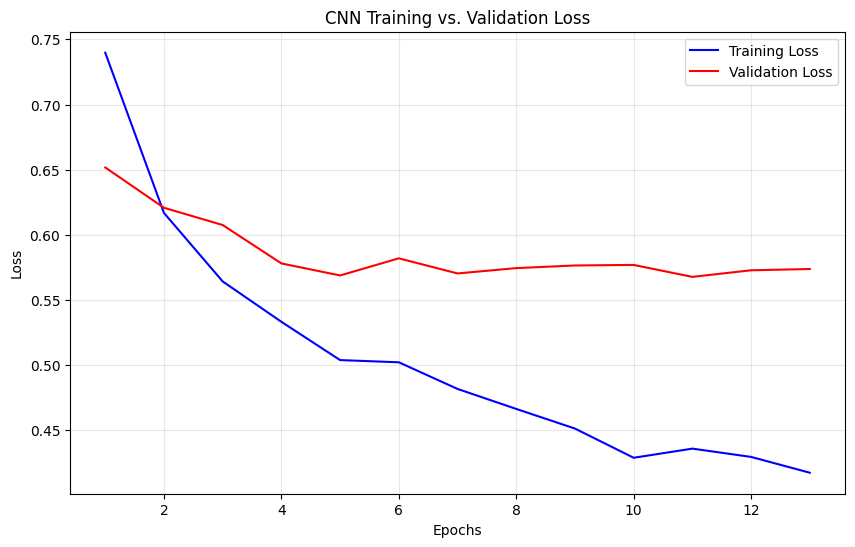

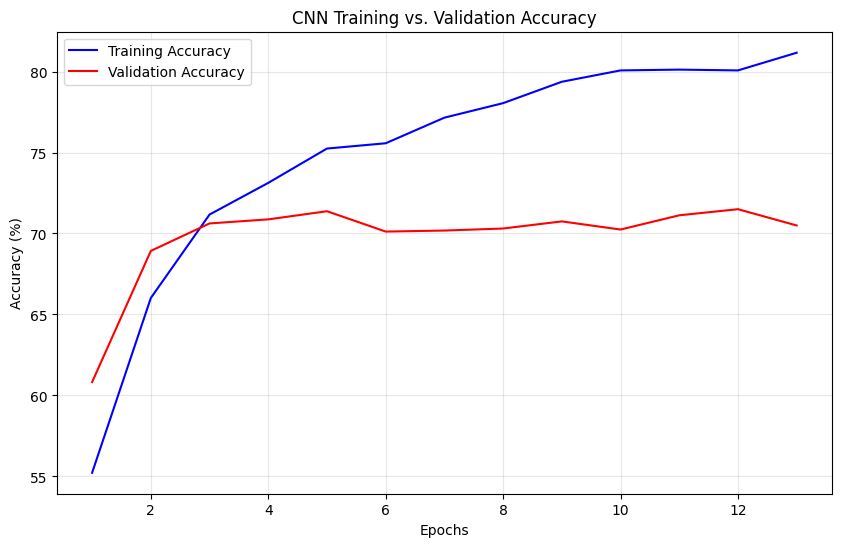

In [37]:
epochs = range(1, len(train_losses) + 1) #plot train and validation loss as a function of #epochs
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_losses, label="Training Loss", color='blue')
plt.plot(epochs, val_losses, label="Validation Loss", color='red')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("CNN Training vs. Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6)) #where the best accuracy was
plt.plot(epochs, [a*100 for a in train_accuracies], label="Training Accuracy", color='blue')
plt.plot(epochs, [a*100 for a in val_accuracies], label="Validation Accuracy", color='red')
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("CNN Training vs. Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [38]:
def evaluate_model(model, val_loader):#evaluation in window level
    model.eval()
    correct = 0
    total = 0
    '''
  #Evaluate a model on the given dataloader.
  #Params:
  #model - a pytorch model to train
  #val_loader - dataloader for the valset
  '''
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    with torch.no_grad():#predictions
        for images, labels, _ in val_loader:
            images, labels = images.to(device), labels.to(device).float().view(-1)
            outputs = model(images).view(-1)
            predicted=(outputs > 0.5).float()
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = correct / total
    return accuracy
val_acc=evaluate_model(model, val_loader)
print(f"Validation Accuracy: {val_acc:.2%}")

Validation Accuracy: 71.12%


In [39]:
def evaluate_model_at_subject_level(model, dataset, groups, device):
    model.eval()
    subj_results = {}

    with torch.no_grad():
        for i in range(len(dataset)):
            x, y, _ = dataset[i]
            subj_id = groups[i]
            output = model(x.unsqueeze(0).to(device))
            prob = output.item()

            if subj_id not in subj_results:
                subj_results[subj_id] = {'probs': [], 'true': y.item()}
            subj_results[subj_id]['probs'].append(prob)

    # Aggregate votes
    final_true = []
    final_pred = []

    for s in subj_results:
        avg_prob = np.mean(subj_results[s]['probs'])
        final_pred.append(1 if avg_prob > 0.5 else 0)
        final_true.append(subj_results[s]['true'])
    return final_true, final_pred

#evaluation
true_vals, pred_vals=evaluate_model_at_subject_level(model, full_dataset, groups_cnn, device)

print("Overall Subject-Level Performance")
print(f"Accuracy: {accuracy_score(true_vals, pred_vals):.3f}")
print("\nDetailed Report:")
print(classification_report(true_vals, pred_vals, target_names=['Preserved', 'Impaired']))

Overall Subject-Level Performance
Accuracy: 0.870

Detailed Report:
              precision    recall  f1-score   support

   Preserved       0.89      0.92      0.91        89
    Impaired       0.82      0.76      0.79        42

    accuracy                           0.87       131
   macro avg       0.86      0.84      0.85       131
weighted avg       0.87      0.87      0.87       131



/tmp/ipython-input-44683/3671465727.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Clinical Tier', y='CNN Impairment Probability', data=df_res, order=order, palette="RdYlGn_r")


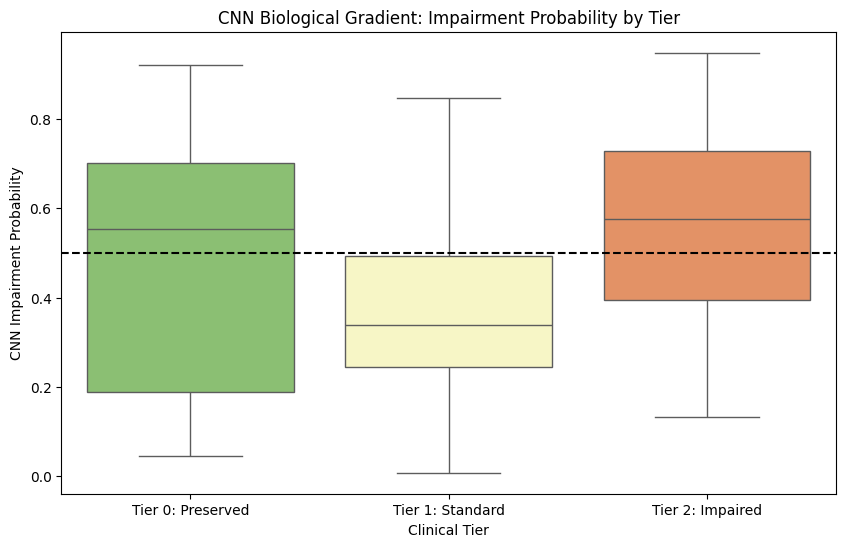

In [40]:
def plot_tiered_progression(model, test_loader):
  model.eval()
  tier_results = {0: [], 1: [], 2: []}

  with torch.no_grad():
    for inputs, _, tiers in test_loader:
      outputs = model(inputs.to(device)).cpu().numpy().flatten()
      ts = tiers.numpy().flatten()
      for prob, t in zip(outputs, ts):
        tier_results[int(t)].append(prob)

  data = []
  tier_mapping = {0: 'Tier 0: Preserved', 1: 'Tier 1: Standard', 2: 'Tier 2: Impaired'}

  for t_idx, label in tier_mapping.items():
    for p in tier_results[t_idx]:
      data.append({'Clinical Tier': label, 'CNN Impairment Probability': p})

  df_res = pd.DataFrame(data)
  plt.figure(figsize=(10, 6))
  order = ['Tier 0: Preserved', 'Tier 1: Standard', 'Tier 2: Impaired']

  sns.boxplot(x='Clinical Tier', y='CNN Impairment Probability', data=df_res, order=order, palette="RdYlGn_r")
  plt.axhline(0.5, color='black', linestyle='--')
  plt.title("CNN Biological Gradient: Impairment Probability by Tier")
  plt.show()


plot_tiered_progression(model, test_loader)

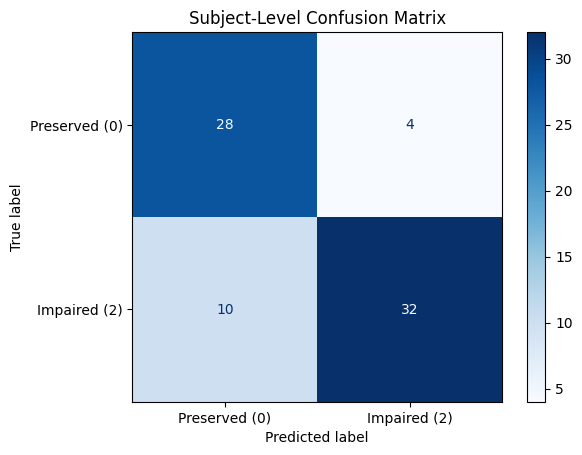

In [41]:
# Aggregate Subject Votes
subject_probs = {}
subject_true_tier = {}

model.eval()
with torch.no_grad():
    for i in range(len(full_dataset)):
        inputs, _, tier = full_dataset[i]
        subj_id = groups_cnn[i]
        output = model(inputs.unsqueeze(0).to(device)).item()

        if subj_id not in subject_probs:
            subject_probs[subj_id] = []
            subject_true_tier[subj_id] = tier.item()
        subject_probs[subj_id].append(output)

# Calculate final votes
final_results = []
for s in subject_probs:
    avg_prob = np.mean(subject_probs[s])
    final_results.append({
        'Subject': s,
        'True_Tier': subject_true_tier[s],
        'CNN_Vote': 1 if avg_prob > 0.5 else 0
    })

res_df = pd.DataFrame(final_results)

# Confusion Matrix for the clear cases (Tier 0 vs Tier 2)
binary_df = res_df[res_df['True_Tier'].isin([0, 2])]
# Map True_Tier 2 to 1 for the CM to match the CNN_Vote (0 or 1)
y_true = binary_df['True_Tier'].replace(2, 1)
y_pred = binary_df['CNN_Vote']

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Preserved (0)', 'Impaired (2)'])
disp.plot(cmap='Blues')
plt.title("Subject-Level Confusion Matrix")
plt.show()

In [42]:
results = [] #training of k-folds, cross validation

for fold_idx, (t_idx, v_idx) in enumerate(folds):
    print(f"Training Fold {fold_idx + 1}")
    t_loader = get_balanced_loader(full_dataset, t_idx)
    v_loader = DataLoader(Subset(full_dataset, v_idx), batch_size=32)
    model = ConvolutionalNet().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cnn_learning_rate)
    trained_model, train_losses, val_losses, train_accuracies, val_accuracies = train_model(model, optimizer, cnn_criterion, 15, t_loader, v_loader)
    results.append(max(val_accuracies))#save the best result

print(f"Average Accuracy across all folds: {np.mean(results):.2f}") #check what is the accuracy when we mix the smples, and that accuracy we found not sample depend and there are no sample bias

Training Fold 1
Epoch 5/15: Train Loss 0.5221, Val Loss 0.5799, Val Acc 0.706
Epoch 10/15: Train Loss 0.4690, Val Loss 0.5713, Val Acc 0.704
Epoch 15/15: Train Loss 0.4079, Val Loss 0.5456, Val Acc 0.721
Training Fold 2
Epoch 5/15: Train Loss 0.5151, Val Loss 0.5414, Val Acc 0.767
Epoch 10/15: Train Loss 0.4475, Val Loss 0.5639, Val Acc 0.750
Stopping because gap (0.1533) exceeded limit (0.15)
Training Fold 3
Epoch 5/15: Train Loss 0.4556, Val Loss 0.6947, Val Acc 0.523
Epoch 10/15: Train Loss 0.4112, Val Loss 0.7288, Val Acc 0.500
Stopping because gap (0.3303) exceeded limit (0.15)
Training Fold 4
Epoch 5/15: Train Loss 0.4930, Val Loss 0.6762, Val Acc 0.589
Epoch 10/15: Train Loss 0.4508, Val Loss 0.6685, Val Acc 0.589
Stopping because gap (0.2302) exceeded limit (0.15)
Training Fold 5
Epoch 5/15: Train Loss 0.4841, Val Loss 0.6431, Val Acc 0.653
Epoch 10/15: Train Loss 0.4245, Val Loss 0.6451, Val Acc 0.653
Stopping because gap (0.2047) exceeded limit (0.15)
Average Accuracy across 

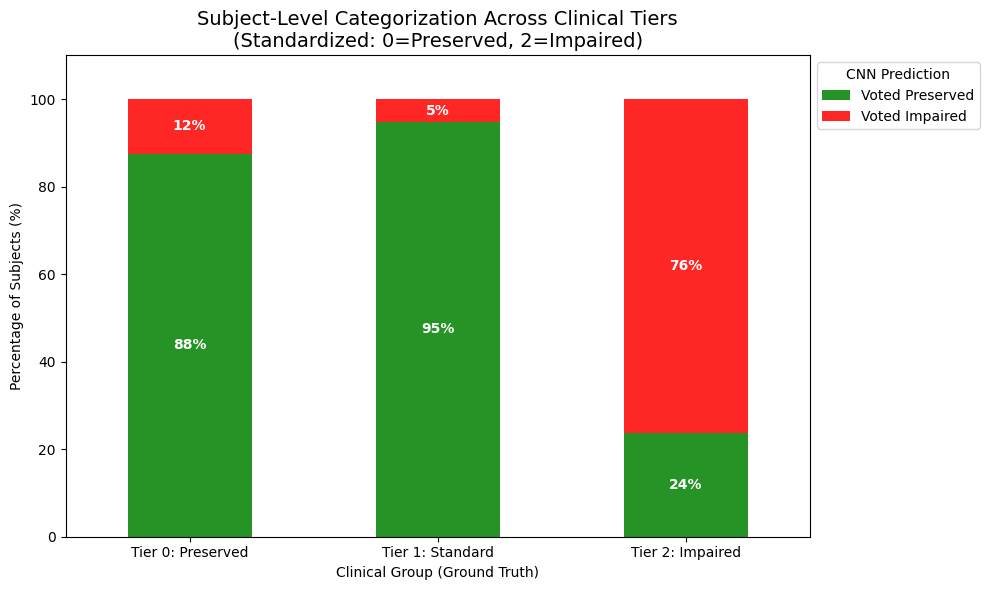

In [43]:
results_df = pd.DataFrame({
  'Subject': list(subject_probs.keys()),
  'Tier': [subject_true_tier[s] for s in subject_probs.keys()],
  'Avg_Prob': [np.mean(subject_probs[s]) for s in subject_probs.keys()]
})

# Define the prediction based on the 0.5 threshold
results_df['CNN_Vote'] = (results_df['Avg_Prob'] > 0.5).astype(int)

# Mapping for the X-axis (Clinical Tiers)
tier_map = {0: 'Tier 0: Preserved', 1: 'Tier 1: Standard', 2: 'Tier 2: Impaired'}
results_df['Tier_Label'] = results_df['Tier'].map(tier_map)

results_df['CNN_Decision'] = results_df['CNN_Vote'].map({0: 'Voted Preserved', 1: 'Voted Impaired'})

# Pivot Table
pivot_df = results_df.groupby(['Tier_Label', 'CNN_Decision']).size().unstack(fill_value=0)

for col in ['Voted Preserved', 'Voted Impaired']:
  if col not in pivot_df.columns:
    pivot_df[col] = 0

# %
# Plotting with logical clinical colors
pivot_df_perc = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100
pivot_df_perc = pivot_df_perc[['Voted Preserved', 'Voted Impaired']]
order = ['Tier 0: Preserved', 'Tier 1: Standard', 'Tier 2: Impaired']
pivot_df_perc = pivot_df_perc.reindex(order)

ax = pivot_df_perc.plot(
  kind='bar',
  stacked=True,
  figsize=(10, 6),
  color=['green', 'red'], # Green for Healthy, Red for Impaired
  alpha=0.85
)

plt.title("Subject-Level Categorization Across Clinical Tiers\n(Standardized: 0=Preserved, 2=Impaired)", fontsize=14)
plt.ylabel("Percentage of Subjects (%)")
plt.xlabel("Clinical Group (Ground Truth)")
plt.xticks(rotation=0)
plt.legend(title="CNN Prediction", loc='upper left', bbox_to_anchor=(1, 1))
plt.ylim(0, 110) # Bumped to 110 to give the top labels some breathing room

# Add percentage labels on the bars for clarity
for p in ax.patches:
  width, height = p.get_width(), p.get_height()
  if height > 5: # Only show label if the segment is visible
    x, y = p.get_xy()
    # Removed 'float_format' - the formatting is handled by the f-string below
    ax.text(
      x + width/2,
      y + height/2,
      f'{height:.0f}%',
      ha='center',
      va='center',
      color='white',
      fontweight='bold'
    )

plt.tight_layout()
plt.show()


The model thinks the "Standard" group looks almost identical to the "Preserved" group.

In [44]:
def delong_roc_variance(y_true, prob):#delong statistic test for compairing AUC between the groups and its significance
    pos=prob[y_true == 1] #Impaired
    neg=prob[y_true == 0] #Preserved
    m, n = len(pos), len(neg)
    v1=(np.sum(pos[:, None] > neg, axis=1) + 0.5 * np.sum(pos[:, None] == neg, axis=1))/n #compute tha varience
    v0=(np.sum(neg[:, None] < pos, axis=1) + 0.5 * np.sum(neg[:, None] == pos, axis=1))/m
    return np.var(v1, ddof=1)/m + np.var(v0, ddof=1)/n

def compare_models_delong(y_true, prob_rf, prob_cnn):
    auc_rf=roc_auc_score(y_true, prob_rf) #AUC computing
    auc_cnn=roc_auc_score(y_true, prob_cnn)
    var_rf=delong_roc_variance(y_true, prob_rf)
    var_cnn=delong_roc_variance(y_true, prob_cnn)
    z_score=(auc_cnn - auc_rf) / np.sqrt(var_rf + var_cnn)#z-score computing
    p_value=2*stats.norm.sf(np.abs(z_score))#p-value computing
    return z_score, p_value, auc_rf, auc_cnn
# ROC vizualization
def plot_model_comparison(y_true, prob_rf, prob_cnn):
    z, p, auc_rf, auc_cnn = compare_models_delong(y_true, prob_rf, prob_cnn)
    fpr_rf, tpr_rf, _ = roc_curve(y_true, prob_rf)
    fpr_cnn, tpr_cnn, _ = roc_curve(y_true, prob_cnn)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', color='blue', linestyle='--')
    plt.plot(fpr_cnn, tpr_cnn, label=f'2D CNN (AUC = {auc_cnn:.3f})', color='red', linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.title('ROC Curve Comparison: RF vs. CNN', fontsize=14)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    stats_text = f"DeLong Test:\nZ-score: {z:.2f}\nP-value: {p:.4f}"
    plt.text(0.5, 0.2, stats_text, bbox=dict(facecolor='white', alpha=0.8))
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.savefig('roc_comparison.png')


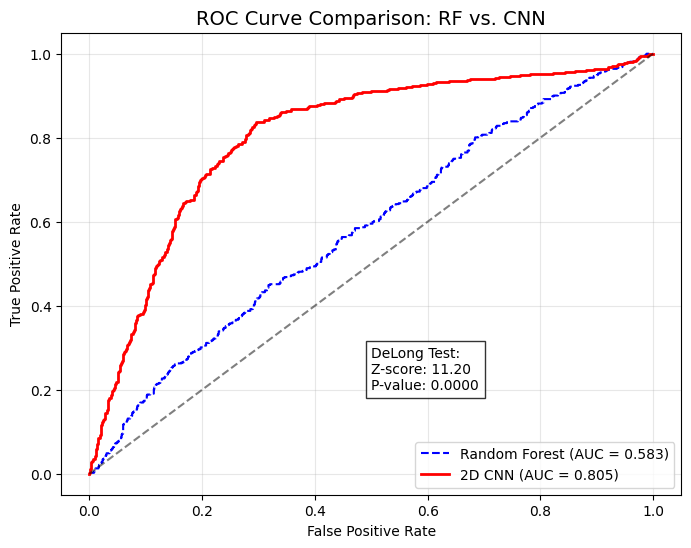


Statistical decision
CNN AUC: 0.8052
RF AUC:  0.5828
P-value: 3.989282e-29


In [45]:
model.eval()
cnn_probs_all = []
y_true_all = []

with torch.no_grad():
    for inputs, labels, _ in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        cnn_probs_all.extend(outputs.cpu().numpy().flatten())
        y_true_all.extend(labels.numpy().flatten())

y_true_all = np.array(y_true_all)
cnn_probs_all = np.array(cnn_probs_all)
#Random forest
X_rf_train = X_cnn_train.mean(axis=(1, 2)) #changing of traing/test values for RF usage
X_rf_test = X_cnn_test.mean(axis=(1, 2))
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=7)
rf_model.fit(X_rf_train, y_cnn_train)
rf_probs_all = rf_model.predict_proba(X_rf_test)[:, 1]

if len(rf_probs_all) != len(cnn_probs_all):
    min_len = min(len(rf_probs_all), len(cnn_probs_all))
    y_true_all = y_true_all[:min_len]
    rf_probs_all = rf_probs_all[:min_len]
    cnn_probs_all = cnn_probs_all[:min_len]

try:
    plot_model_comparison(y_true_all, rf_probs_all, cnn_probs_all)
    plt.show()
except Exception as e:
    print(f"Error: {e}")

# final statistical decision
z, p, auc_rf, auc_cnn = compare_models_delong(y_true_all, rf_probs_all, cnn_probs_all)
print(f"\nStatistical decision")
print(f"CNN AUC: {auc_cnn:.4f}")
print(f"RF AUC:  {auc_rf:.4f}")
print(f"P-value: {p:.6e}")

In our project we have 149 participants with about 8000 spectrograms in total. To investigate the strength of our results, and check the significance of AUC results we propose the DeLong test for comparing the AUCs of Spectrogram CNN model (AUC=0.81) vs Random forest (AUC=0.58) of the same data as a baseline. Random forest was chosen as a comparison because this method can’t use spatial information (channel power), so that way we can ensure if deep learning adds an additional ability by learning spatial patterns. Also, that comparison enables us to show the basic accuracy that very simple models like random forest achieve and underline the advantage of deep learning on it.    
ROC curve illustrates the trade-off between the True Positive Rate and False positive (shows the ratio between True positive and False positive) for each sample in different thresholds, and provides the visual representation of how much every sample, its prediction contributes to the model and its separability. A higher curve indicates superior separability, meaning the model is more effective at distinguishing between Impaired patients and Preserved controls. As we can see CNN cognitive spectrogram model is much more separable, with high z-score and low p-value, that support the significance of AUC differences.
The CNN model demonstrates significantly higher separability, supported by a high Z-score (11) and a low p-value (<0.001), which supports the significance of AUC difference.
These results demonstrate the appearance of complex cognitive spatial-temporal patterns in EEG of Parkinson's patients that can’t be captured by traditional simple machine learning methods like Random forest. Accordingly, a deep learning approach is essential for achieving cognitive based PD cognitive classification.


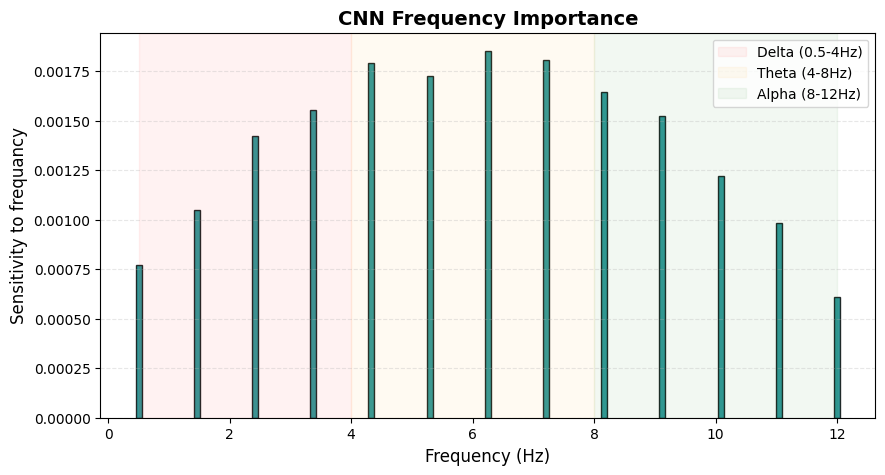

In [46]:
#which spesific frequancies cause to CNN to  chouse if the sample in one group or another
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()
ig = IntegratedGradients(model)#mesure the contribution of each input feature to model output, comput gradient for every step and integrates them
plt.clf()
plt.close('all')

test_input = torch.tensor(X_cnn_test[:100]).float().to(device)
test_input.requires_grad_()

#feature contribution to the model acording to test
attributes = ig.attribute(test_input, target=None)
importance_per_feature = attributes.abs().mean(dim=(0, 1, 2)).detach().cpu().numpy()


freq_axis = np.linspace(0.5, 12, len(importance_per_feature))
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(freq_axis, importance_per_feature, width=0.1, color='teal', edgecolor='black', alpha=0.8)
ax.axvspan(0.5, 4, color='red', alpha=0.05, label='Delta (0.5-4Hz)')
ax.axvspan(4, 8, color='orange', alpha=0.05, label='Theta (4-8Hz)')
ax.axvspan(8, 12, color='green', alpha=0.05, label='Alpha (8-12Hz)')
ax.set_title("CNN Frequency Importance", fontsize=14, fontweight='bold')
ax.set_xlabel("Frequency (Hz)", fontsize=12)
ax.set_ylabel("Sensitivity to frequancy", fontsize=12)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()